# All Resting State EEG

## Eyes Closed

In [102]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from scipy.signal import welch

# St div. Version

### No Aces

In [103]:
no_aces_EC = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed"
print(os.path.exists(no_aces_EC))

True


In [104]:
files = glob.glob(os.path.join(no_aces_EC, "*AveOverTrials.txt"))

fs = 500  

In [105]:
all_subject_psd_ec = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_ec.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_ec))

Subjects: 47


In [106]:
print(signals.shape)

(2000, 19)


In [107]:
all_subject_psd_ec = np.vstack(all_subject_psd_ec)

group_psd_ec = np.mean(all_subject_psd_ec, axis=0)

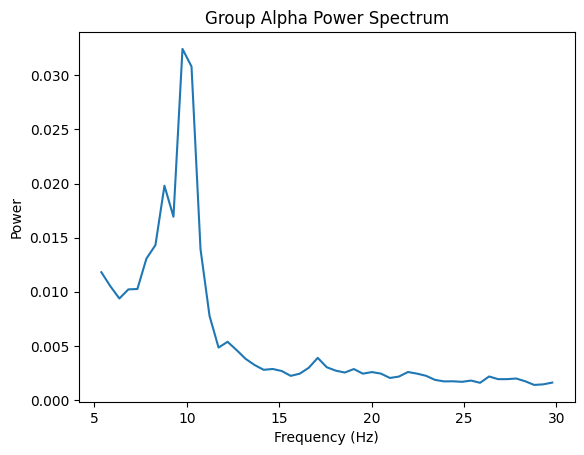

In [108]:
alpha_mask = (freqs >= 5) & (freqs <= 30)

plt.plot(freqs[alpha_mask], group_psd_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

#### 2nd version no Aces EC

In [109]:
eps = 1e-12
log_psd = np.log10(group_psd_ec + eps)

In [110]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm_ec = log_psd - baseline

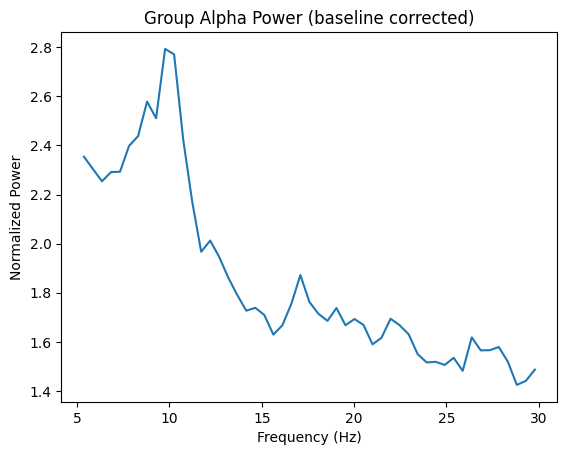

In [111]:
plt.plot(freqs[alpha_mask], log_psd_norm_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z-Score No_ACEs EC

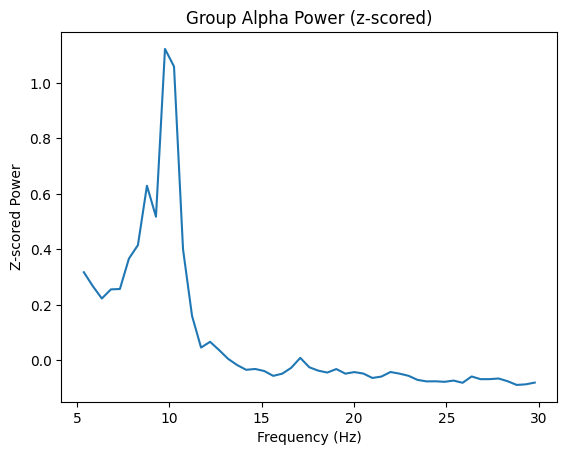

In [112]:
psd_mean_ec = np.mean(group_psd_ec)
psd_std_ec = np.std(group_psd_ec)
psd_z_ec = (group_psd_ec - psd_mean_ec) / psd_std_ec

plt.plot(freqs[alpha_mask], psd_z_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### Centered UV version No_ACEs EC

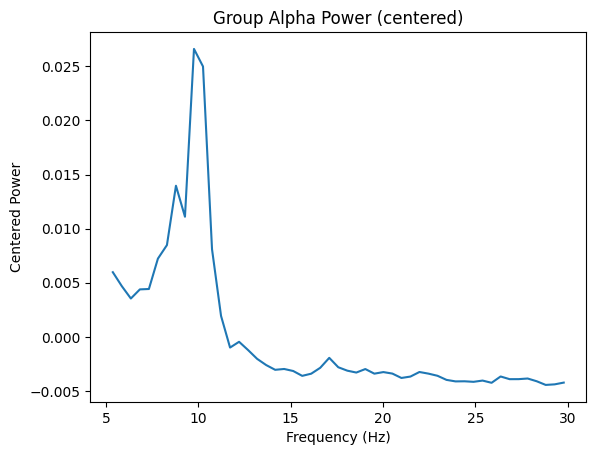

In [113]:

alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_centered_ec = alpha_power_ec - np.mean(alpha_power_ec)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z-Score version

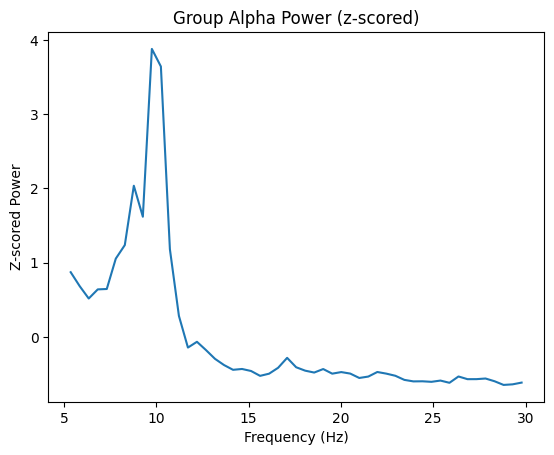

In [114]:
alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_z_ec = (alpha_power_ec - np.mean(alpha_power_ec)) / np.std(alpha_power_ec)

plt.plot(freqs[alpha_mask], alpha_power_z_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

## ACEs EC

In [115]:
aces_ec = "C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed\\EC_ACES"
print(os.path.exists(aces_ec))

True


In [116]:
files = glob.glob(os.path.join(aces_ec, "*AveOverTrials.txt"))

fs = 500 

In [117]:
all_subject_psd_ace_ec = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_ace_ec.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_ace_ec))

Subjects: 151


In [118]:
all_subject_psd_ace_ec = np.vstack(all_subject_psd_ace_ec)

group_psd_ace_ec = np.mean(all_subject_psd_ace_ec, axis=0)

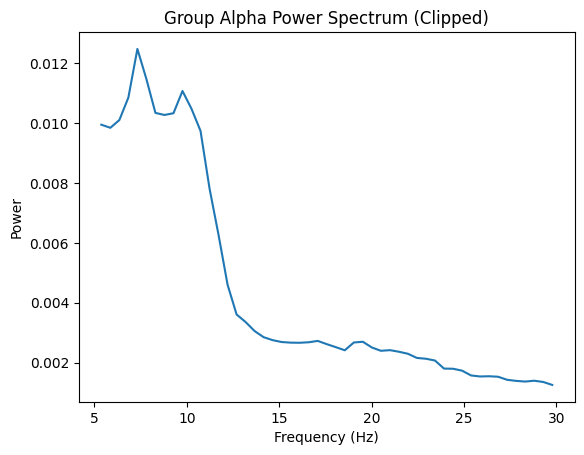

In [119]:
# Plot
plt.plot(freqs[alpha_mask], group_psd_ace_ec[alpha_mask], label="Original")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum (Clipped)")
plt.show()

#### 2nd visual ACEs EC

In [120]:
eps = 1e-12
log_psd = np.log10(group_psd_ace_ec + eps)

In [121]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm_ace_ec = log_psd - baseline

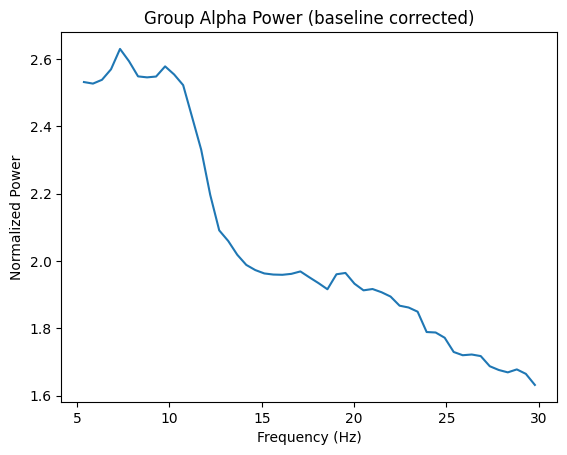

In [122]:
plt.plot(freqs[alpha_mask], log_psd_norm_ace_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z-score of 2nd verison

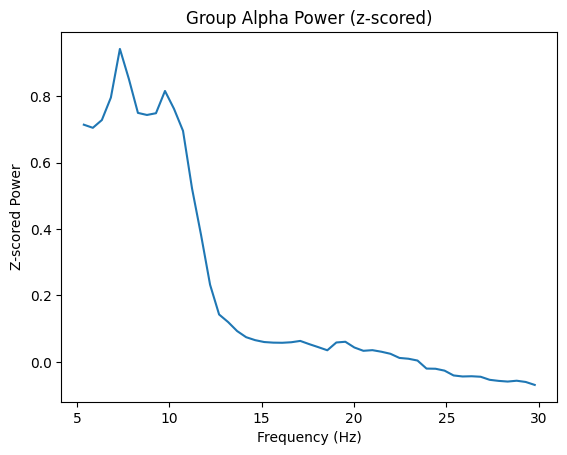

In [123]:
psd_mean = np.mean(group_psd_ace_ec)
psd_std = np.std(group_psd_ace_ec)
psd_z_ace_ec = (group_psd_ace_ec - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z_ace_ec[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### UV version [center]

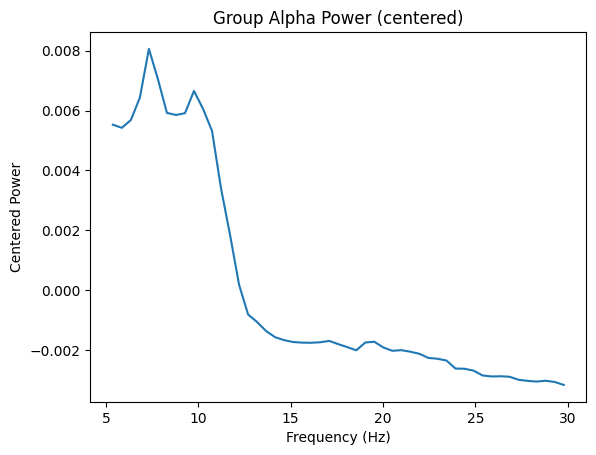

In [124]:
alpha_power_aces_ec = group_psd_ace_ec[alpha_mask]
alpha_power_centered_aces_ec = alpha_power_aces_ec - np.mean(alpha_power_aces_ec)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_aces_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z-score of UV

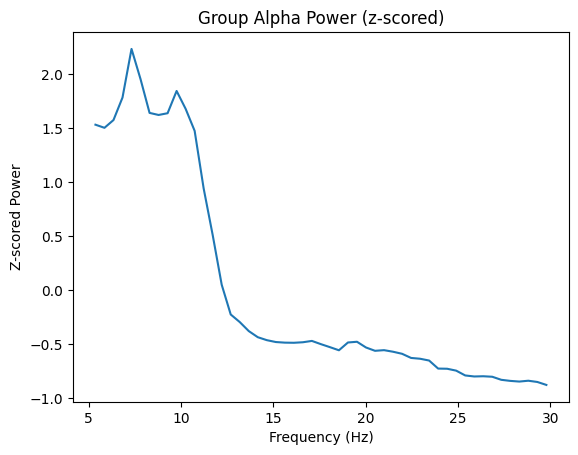

In [125]:
alpha_power_aces_ec = group_psd_ace_ec[alpha_mask]
alpha_power_z_ace_ec = (alpha_power_aces_ec - np.mean(alpha_power_aces_ec)) / np.std(alpha_power_aces_ec)

plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

# Eyes Open

## No ACEs

In [126]:
no_aces ="C:\\Users\\emros\\OneDrive\\Desktop\\EO_No_ACES_ processed"
print(os.path.exists(no_aces))

True


In [127]:
files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))

fs = 500 

In [128]:
all_subject_psd = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd))

Subjects: 48


In [129]:
all_subject_psd = np.vstack(all_subject_psd)

group_psd = np.mean(all_subject_psd, axis=0)

#### Visual 1

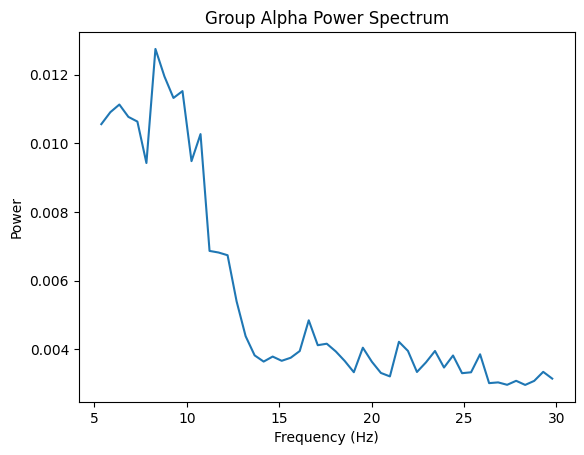

In [130]:
plt.plot(freqs[alpha_mask], group_psd[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

#### 2nd better version

In [131]:
eps = 1e-12
log_psd = np.log10(group_psd + eps)

In [132]:
# baseline = mean across all frequencies
baseline = np.mean(log_psd)
log_psd_norm = log_psd - baseline

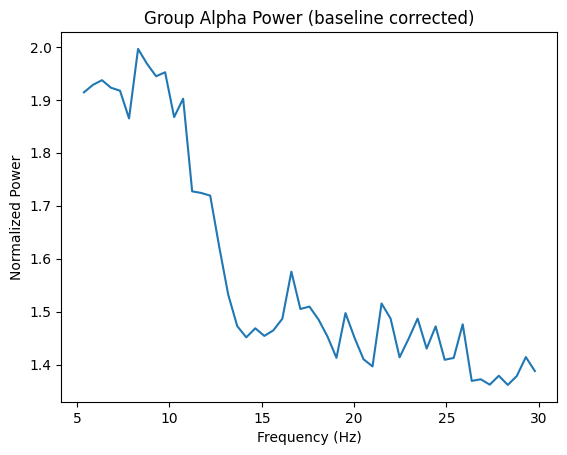

In [133]:
plt.plot(freqs[alpha_mask], log_psd_norm[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

#### Z score

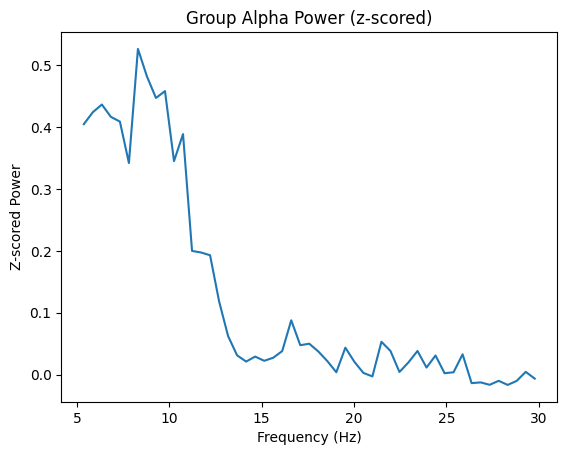

In [134]:
psd_mean = np.mean(group_psd)
psd_std = np.std(group_psd)
psd_z = (group_psd - psd_mean) / psd_std

plt.plot(freqs[alpha_mask], psd_z[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

#### Anotha one (UV version)

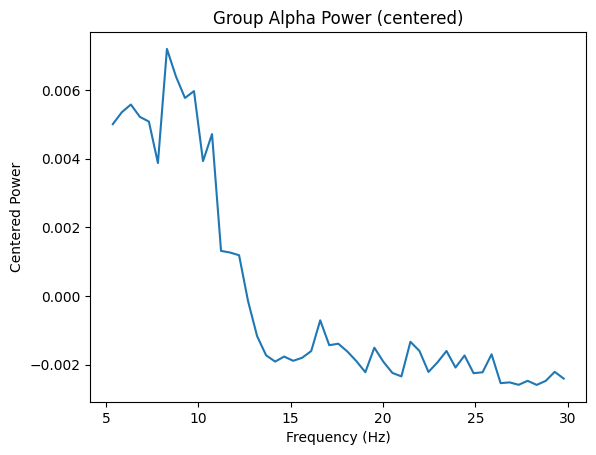

In [135]:
alpha_power = group_psd[alpha_mask]
alpha_power_centered = alpha_power - np.mean(alpha_power)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

#### Z score or UV

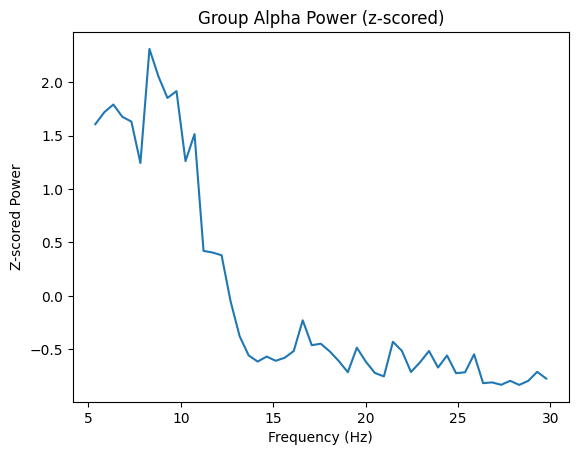

In [136]:
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

plt.plot(freqs[alpha_mask], alpha_power_z)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

## ACEs {EO}

In [137]:
ACEs = "C:\\Users\\emros\\OneDrive\\Desktop\\EO_ACES_Processed"

In [138]:
files = glob.glob(os.path.join(ACEs, "*AveOverTrials.txt"))

fs = 500

In [139]:
all_subject_psd_aces = []
freqs = None

for f in files:

    # Skip header row
    data = np.genfromtxt(f, skip_header=1)

    # Extract signal
    time = data[:,0]
    signals = data[:,1:]   # electrodes

    # Compute PSD per electrode
    elec_psds = []

    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)

    # Average electrodes
    mean_psd = np.mean(elec_psds, axis=0)

    all_subject_psd_aces.append(mean_psd)

    if freqs is None:
        freqs = f_psd

print("Subjects:", len(all_subject_psd_aces))

Subjects: 88


In [140]:
all_subject_psd_ACE = np.vstack(all_subject_psd_aces)

group_psd_ACE = np.mean(all_subject_psd_ACE, axis=0)

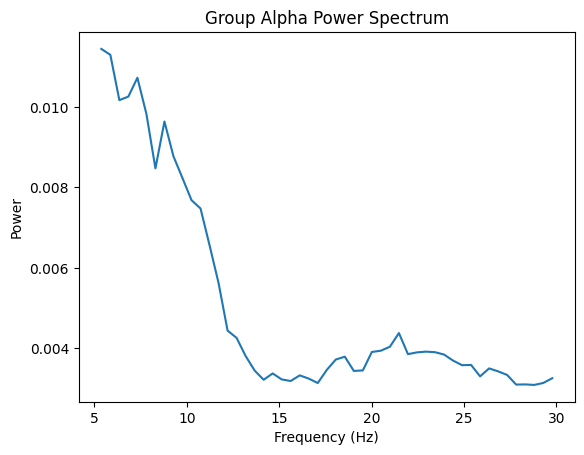

In [141]:
plt.plot(freqs[alpha_mask], group_psd_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Group Alpha Power Spectrum")
plt.show()

In [142]:
eps = 1e-12
log_psd_ace = np.log10(group_psd_ACE + eps)

In [143]:
# baseline = mean across all frequencies
baseline_ace = np.mean(log_psd_ace)
log_psd_norm_ACE = log_psd_ace - baseline_ace

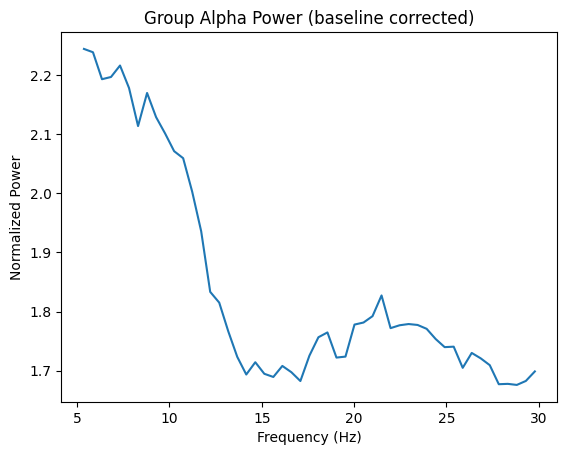

In [144]:
plt.plot(freqs[alpha_mask], log_psd_norm_ACE[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Power")
plt.title("Group Alpha Power (baseline corrected)")
plt.show()

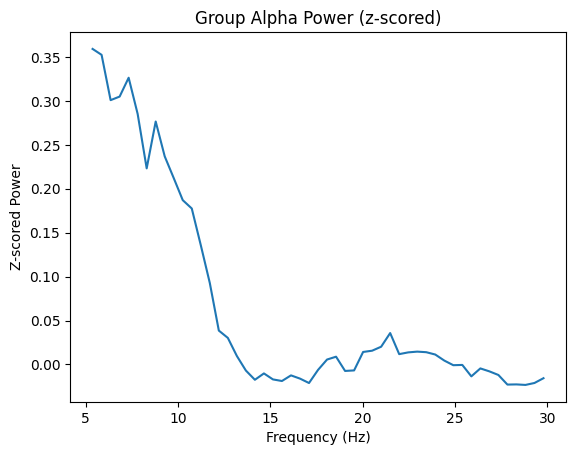

In [145]:
psd_mean_ace = np.mean(group_psd_ACE)
psd_std_ace = np.std(group_psd_ACE)
psd_z_ace = (group_psd_ACE - psd_mean_ace) / psd_std_ace

plt.plot(freqs[alpha_mask], psd_z_ace[alpha_mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

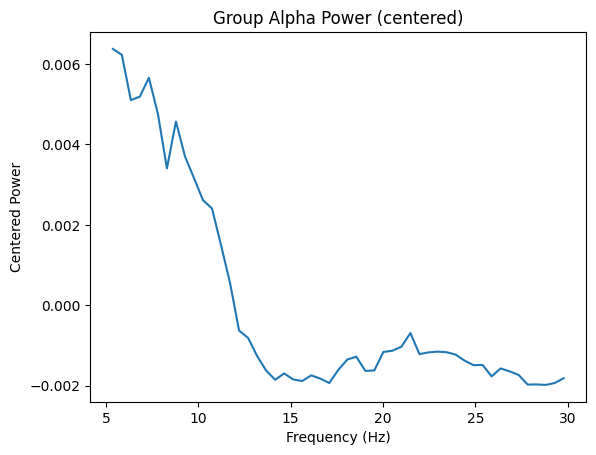

In [146]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_centered_ace = alpha_power_ace - np.mean(alpha_power_ace)  # now has negatives

plt.plot(freqs[alpha_mask], alpha_power_centered_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Centered Power")
plt.title("Group Alpha Power (centered)")
plt.show()

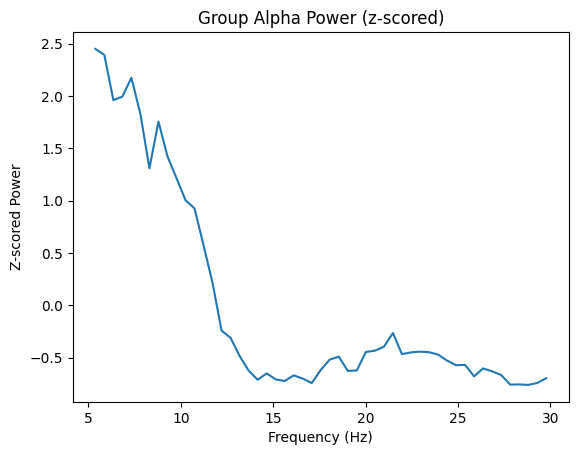

In [147]:
alpha_power_ace = group_psd_ACE[alpha_mask]
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

plt.plot(freqs[alpha_mask], alpha_power_z_ace)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.show()

DIY

In [211]:
import os
import numpy as np
import pandas as pd
import glob
from scipy.signal import welch

fs = 500

def compute_mean_psd(file):
    data = np.genfromtxt(file, skip_header=1)
    signals = data[:, 1:]

    elec_psds = []
    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:, e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)
    mean_psd = np.mean(elec_psds, axis=0)

    return f_psd, mean_psd

In [212]:
def compute_group(ec_folder, eo_folder, group_name):

    ec_files = sorted(glob.glob(os.path.join(ec_folder, "*AveOverTrials.txt")))
    eo_files = sorted(glob.glob(os.path.join(eo_folder, "*AveOverTrials.txt")))

    results = []

    for ec_f, eo_f in zip(ec_files, eo_files):

        subject_id = os.path.basename(ec_f).split("_")[0]

        f_ec, psd_ec = compute_mean_psd(ec_f)
        f_eo, psd_eo = compute_mean_psd(eo_f)

        assert np.allclose(f_ec, f_eo)
        freqs = f_ec

        eps = 1e-12
        log_ec = np.log10(psd_ec + eps)
        log_eo = np.log10(psd_eo + eps)

        diff = log_ec - log_eo  # EC - EO

        alpha_mask = (freqs >= 8) & (freqs <= 12)

        auc = np.trapz(diff[alpha_mask], freqs[alpha_mask])

        results.append({
            "subject": subject_id,
            "group": group_name,
            "auc": auc
        })

    return pd.DataFrame(results)

In [213]:
no_aces_df = compute_group(
    ec_folder="C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed",
    eo_folder="C:\\Users\\emros\\OneDrive\\Desktop\\EO_No_ACES_ processed",
    group_name="no_aces"
)

aces_df = compute_group(
    ec_folder="C:\\Users\\emros\\OneDrive\\Desktop\\4 - processed\\EC_ACES",
    eo_folder="C:\\Users\\emros\\OneDrive\\Desktop\\EO_ACES_Processed",
    group_name="aces"
)

df = pd.concat([no_aces_df, aces_df], ignore_index=True)

C:\Users\emros\AppData\Local\Temp\ipykernel_33984\2164542213.py:26: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(diff[alpha_mask], freqs[alpha_mask])


In [223]:
from scipy.stats import ttest_ind

aces = df[df.group == "aces"]["auc"].values
no_aces = df[df.group == "no_aces"]["auc"].values

t_stat, p_val = ttest_ind(aces, no_aces, equal_var=False)

print("t =", t_stat)
print("p =", p_val)

t = -0.1323827960082835
p = 0.895024454835065


# Final Visuals

### Eyes open

In [148]:
alpha_mask = (freqs >= 5) & (freqs <= 30)

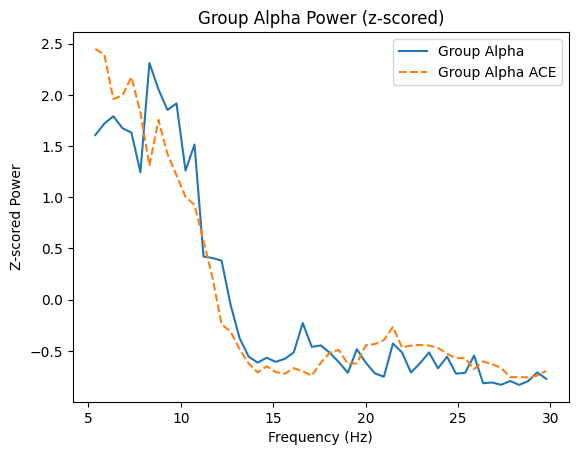

In [149]:
# First line
alpha_power = group_psd[alpha_mask]
alpha_power_z = (alpha_power - np.mean(alpha_power)) / np.std(alpha_power)

# Second line (ACE)
alpha_power_ace = group_psd_ACE[alpha_mask]  # use the actual ACE data here
alpha_power_z_ace = (alpha_power_ace - np.mean(alpha_power_ace)) / np.std(alpha_power_ace)

# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z, label="Group Alpha")
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Group Alpha ACE", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

### Eyes Closed

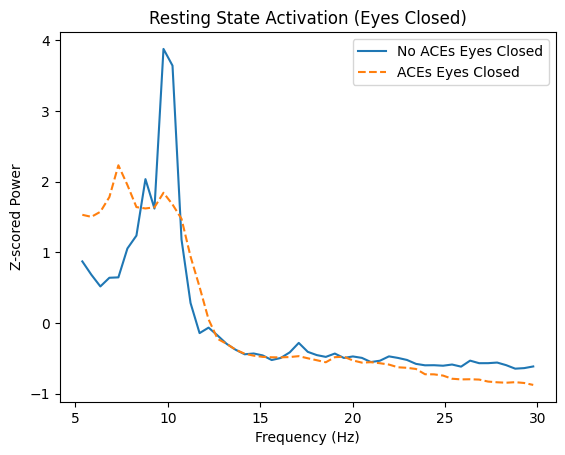

In [150]:
# First line
alpha_power_ec = group_psd_ec[alpha_mask]
alpha_power_z_ec = (alpha_power_ec - np.mean(alpha_power_ec)) / np.std(alpha_power_ec)

# Second line (ACE)
alpha_power_ace_ec = group_psd_ace_ec[alpha_mask]
alpha_power_z_ace_ec = (alpha_power_ace_ec - np.mean(alpha_power_ace_ec)) / np.std(alpha_power_ace_ec)

# Frequencies used in the plot
freq_alpha = freqs[alpha_mask]

# Create dataframe
df = pd.DataFrame({
    "Frequency (Hz)": freq_alpha,
    "No ACEs Eyes Closed (Z Power)": alpha_power_z_ec,
    "ACEs Eyes Closed (Z Power)": alpha_power_z_ace_ec
})

# Save to Excel
df.to_excel("alpha_power_data.xlsx", index=False)

# Plot both on same figure
plt.plot(freq_alpha, alpha_power_z_ec, label="No ACEs Eyes Closed")
plt.plot(freq_alpha, alpha_power_z_ace_ec, label="ACEs Eyes Closed", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Resting State Activation (Eyes Closed)")
plt.legend()
plt.show()

# All

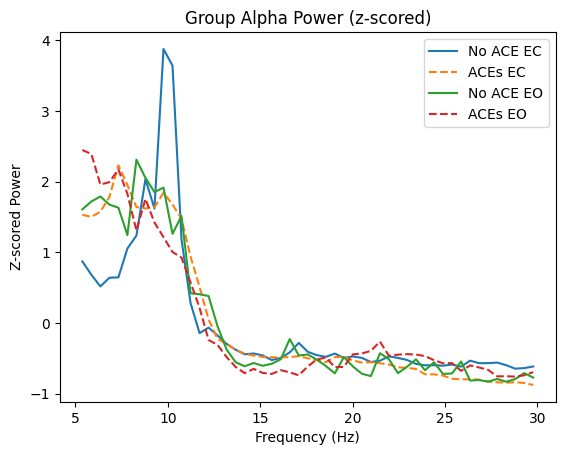

In [151]:
# Frequencies used for plotting
freq_alpha = freqs[alpha_mask]

# Create dataframe with all plotted data
df = pd.DataFrame({
    "Frequency (Hz)": freq_alpha,
    "No ACE EC": alpha_power_z_ec,
    "ACEs EC": alpha_power_z_ace_ec,
    "No ACE EO": alpha_power_z,
    "ACEs EO": alpha_power_z_ace
})

# Save to Excel
df.to_excel("group_alpha_power_zscored.xlsx", index=False)

# Plot both on same figure
plt.plot(freq_alpha, alpha_power_z_ec, label="No ACE EC")
plt.plot(freq_alpha, alpha_power_z_ace_ec, label="ACEs EC", linestyle='--')

plt.plot(freq_alpha, alpha_power_z, label="No ACE EO")
plt.plot(freq_alpha, alpha_power_z_ace, label="ACEs EO", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Z-scored Power")
plt.title("Group Alpha Power (z-scored)")
plt.legend()
plt.show()

### ACES

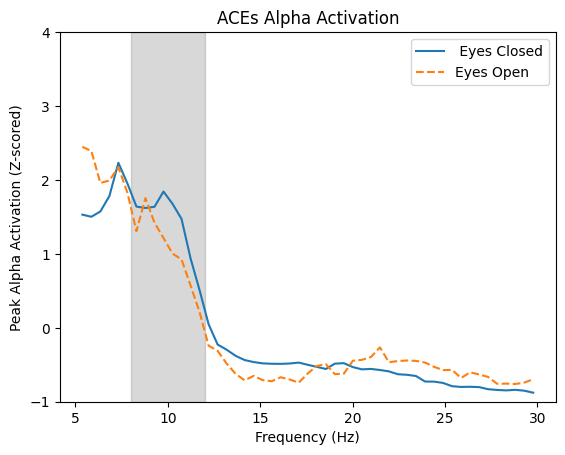

In [152]:
# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec, label=" Eyes Closed")

plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="Eyes Open", linestyle='--')

plt.xlabel("Frequency (Hz)")
plt.ylabel("Peak Alpha Activation (Z-scored)")
plt.title("ACEs Alpha Activation")
plt.axvspan(8, 12, color='gray', alpha=0.3, zorder=0)
plt.ylim(-1, 4)  # <-- set y-axis range
plt.legend()

plt.show()

### No Aces

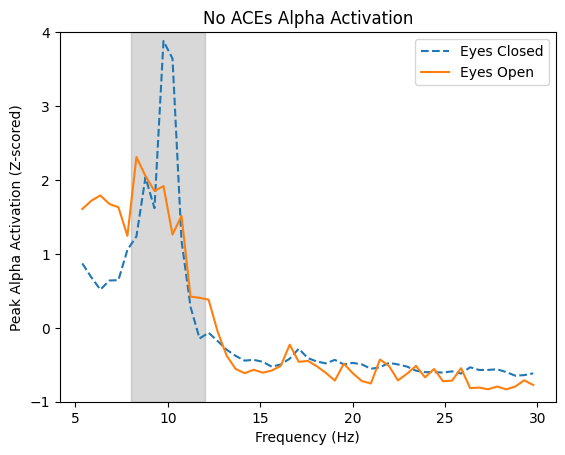

In [153]:
# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ec, label="Eyes Closed", linestyle='--')

plt.plot(freqs[alpha_mask], alpha_power_z, label="Eyes Open")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Peak Alpha Activation (Z-scored)")
plt.title("No ACEs Alpha Activation")
plt.legend()
plt.axvspan(8, 12, color='gray', alpha=0.3, zorder=0)
plt.ylim(-1, 4)  # <-- set y-axis range
plt.show()




# Eyes Closed

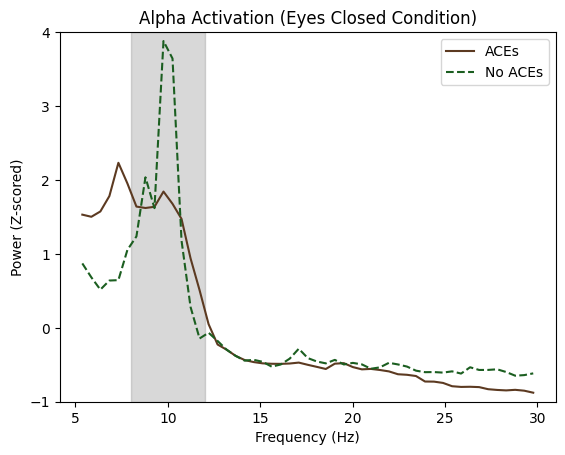

In [232]:
# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ace_ec, label="ACEs", color="#5C3A21")  # dark brown
plt.plot(freqs[alpha_mask], alpha_power_z_ec, label="No ACEs", linestyle='--', color="#1B5E20")  # dark green

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Z-scored)")
plt.title("Alpha Activation (Eyes Closed Condition)")
plt.legend()

plt.ylim(-1, 4)  # set y-axis range
plt.axvspan(8, 12, color='gray', alpha=0.3, zorder=0)

# Eyes Open

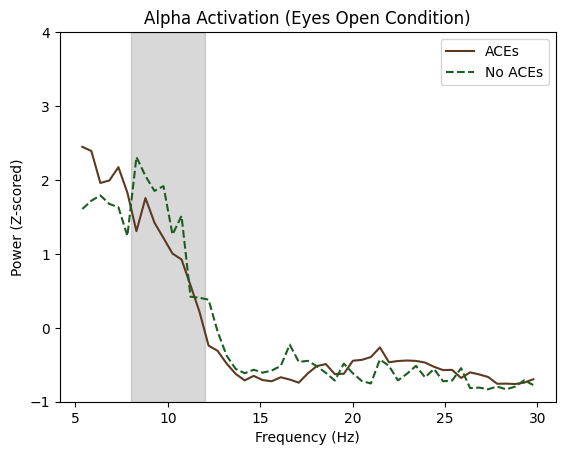

In [231]:
# Plot both on same figure
plt.plot(freqs[alpha_mask], alpha_power_z_ace, label="ACEs", color="#5C3A21")  # dark brown
plt.plot(freqs[alpha_mask], alpha_power_z, label="No ACEs", linestyle='--', color="#1B5E20")  # dark green

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Z-scored)")
plt.title("Alpha Activation (Eyes Open Condition)")
plt.legend()

plt.ylim(-1, 4)  # set y-axis range
plt.axvspan(8, 12, color='gray', alpha=0.3, zorder=0)

#### NO Aces Eyes Closed

In [156]:
peak_freq_ec = freqs[alpha_mask][np.argmax(alpha_power_ec)]

In [157]:
print(peak_freq_ec)

9.765625


#### Aces Eyes Closed

In [158]:
peak_freq_ace_ec = freqs[alpha_mask][np.argmax(alpha_power_ace_ec)]

In [159]:
print(peak_freq_ace_ec)

7.32421875


#### NO Aces Eyes Open

In [160]:
peak_freq_eo = freqs[alpha_mask][np.argmax(alpha_power)]

In [161]:
print(peak_freq_eo)

8.30078125


#### Aces Eyes Open

In [162]:
peak_freq_aces_eo = freqs[alpha_mask][np.argmax(alpha_power_ace)] 

In [163]:
print(peak_freq_aces_eo)

5.37109375


### ACEs

In [164]:
peak_aces = peak_freq_ace_ec - peak_freq_aces_eo

In [165]:
print(peak_aces)

1.953125


### No ACES

In [166]:
peak_no_aces= peak_freq_ec -peak_freq_eo

In [167]:
print(peak_no_aces)

1.46484375


# T Test

In [168]:

aces_diff = alpha_power_z_ace_ec- alpha_power_z_ace
print(alpha_power_z_ace_ec)

[ 1.53077059  1.50191287  1.57379565  1.78195521  2.23209476  1.95246466
  1.63993665  1.62075672  1.63689581  1.84289939  1.67763676  1.47352053
  0.94010829  0.50967961  0.04941519 -0.22596625 -0.29605994 -0.37953418
 -0.43621535 -0.46362697 -0.48098494 -0.48661153 -0.48786311 -0.48305941
 -0.47067931 -0.50059382 -0.52836207 -0.55725292 -0.48519642 -0.4784616
 -0.53145073 -0.56219851 -0.55620464 -0.57078646 -0.58982913 -0.62823322
 -0.63565621 -0.65226762 -0.72668427 -0.72827454 -0.74577153 -0.79028255
 -0.79980523 -0.79772756 -0.80230318 -0.83063894 -0.84065695 -0.84685168
 -0.83911424 -0.85065795 -0.87797973]


In [169]:
no_aces_diff = alpha_power_z_ec - alpha_power_z
print(no_aces_diff)


[-0.73621055 -1.03653343 -1.27431255 -1.03587091 -0.98656502 -0.18971941
 -1.07465186 -0.01743041 -0.23339067  1.96314641  2.38177687 -0.33395082
 -0.13892704 -0.55063488 -0.44737198 -0.12753114  0.0801554   0.17641411
  0.17009273  0.13451355  0.14688183  0.05283159  0.01947    -0.18884353
  0.17798064  0.03751475  0.06378968  0.12845974  0.27999246 -0.01167176
  0.14116202  0.22545386  0.19898028 -0.10602606  0.04090905  0.21587821
  0.09716587 -0.06475837  0.06971529 -0.04145676  0.11683522  0.12523702
 -0.07300842  0.28193451  0.23872578  0.26175903  0.23277686  0.23445523
  0.14720428  0.07043148  0.15722181]


In [170]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(aces_diff, no_aces_diff, equal_var=False)

print(f"t = {t_stat:.3f}, p = {p_val:.4f}")

t = -0.000, p = 1.0000


# Coens

In [171]:
import numpy as np

mean_aces = np.mean(aces_diff)
mean_no_aces = np.mean(no_aces_diff)

std_aces = np.std(aces_diff, ddof=1)
std_no_aces = np.std(no_aces_diff, ddof=1)

n1 = len(aces_diff)
n2 = len(no_aces_diff)

# pooled standard deviation
pooled_std = np.sqrt(((n1 - 1)*std_aces**2 + (n2 - 1)*std_no_aces**2) / (n1 + n2 - 2))

cohens_d = (mean_aces - mean_no_aces) / pooled_std

print(f"Cohen's d = {cohens_d:.3f}")

Cohen's d = -0.000


# AUC

In [172]:
import numpy as np
from scipy.signal import welch

fs = 500

def compute_mean_psd(file):
    data = np.genfromtxt(file, skip_header=1)
    signals = data[:,1:]

    elec_psds = []
    for e in range(signals.shape[1]):
        f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
        elec_psds.append(pxx)

    elec_psds = np.array(elec_psds)
    mean_psd = np.mean(elec_psds, axis=0)

    return f_psd, mean_psd

In [173]:
def compute_diff_auc(ec_files, eo_files):
    aucs = []
    freqs = None

    for ec_f, eo_f in zip(ec_files, eo_files):

        f_ec, psd_ec = compute_mean_psd(ec_f)
        f_eo, psd_eo = compute_mean_psd(eo_f)

        # safety check
        assert np.allclose(f_ec, f_eo)

        freqs = f_ec

        # log transform (recommended)
        eps = 1e-12
        log_ec = np.log10(psd_ec + eps)
        log_eo = np.log10(psd_eo + eps)

        # DIFFERENCE (activation change)
        diff = log_ec - log_eo   # EC - EO

        # frequency band
        alpha_mask = (freqs >= 8) & (freqs <= 12)

        # AUC of difference
        auc = np.trapz(diff[alpha_mask], freqs[alpha_mask])
        aucs.append(auc)

    return aucs

# AUC

In [174]:
import numpy as np

In [175]:
auc_values = []

for subj_psd in all_subject_psd:
    eps = 1e-12
    log_psd = np.log10(subj_psd + eps)

    # choose the same normalization you used
    baseline = np.mean(log_psd)
    log_psd_norm = log_psd - baseline

    # restrict to frequency range (e.g., alpha or full)
    auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])
    
    auc_values.append(auc)

C:\Users\emros\AppData\Local\Temp\ipykernel_33984\81608799.py:12: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])


In [176]:
no_aces_ec_files = glob.glob(os.path.join(no_aces_EC, "*AveOverTrials.txt"))
aces_ec_files = glob.glob(os.path.join(aces_ec, "*AveOverTrials.txt"))

In [177]:
no_aces_eo_files = glob.glob(os.path.join(no_aces, "*AveOverTrials.txt"))
aces_eo_files = glob.glob(os.path.join(ACEs, "*AveOverTrials.txt"))

In [178]:
def compute_auc(files):
    aucs = []
    for f in files:
        data = np.genfromtxt(f, skip_header=1)
        signals = data[:,1:]

        elec_psds = []
        for e in range(signals.shape[1]):
            f_psd, pxx = welch(signals[:,e], fs=fs, nperseg=1024)
            elec_psds.append(pxx)

        elec_psds = np.array(elec_psds)
        mean_psd = np.mean(elec_psds, axis=0)

        eps = 1e-12
        log_psd = np.log10(mean_psd + eps)
        baseline = np.mean(log_psd)
        log_psd_norm = log_psd - baseline

        auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])
        aucs.append(auc)

    return aucs

In [179]:
no_aces_ec_auc = compute_auc(no_aces_ec_files)
aces_ec_auc = compute_auc(aces_ec_files)

C:\Users\emros\AppData\Local\Temp\ipykernel_33984\3984123654.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])


In [180]:
no_aces_eo_auc = compute_auc(no_aces_eo_files)
aces_eo_auc = compute_auc(aces_eo_files)

C:\Users\emros\AppData\Local\Temp\ipykernel_33984\3984123654.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(log_psd_norm[alpha_mask], freqs[alpha_mask])


In [181]:
no_aces_auc_diff = compute_diff_auc(no_aces_ec_files, no_aces_eo_files)
aces_auc_diff = compute_diff_auc(aces_ec_files, aces_eo_files)

C:\Users\emros\AppData\Local\Temp\ipykernel_33984\1305779468.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(diff[alpha_mask], freqs[alpha_mask])


In [182]:
print("No ACEs mean AUC EC:", np.mean(no_aces_ec_auc))
print("ACEs mean AUC EC:", np.mean(aces_ec_auc))

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(no_aces_ec_auc, aces_ec_auc)
print("t =", t_stat, "p =", p_val)

No ACEs mean AUC EC: 51.62415833915557
ACEs mean AUC EC: 54.5012634265104
t = -1.7967786674571045 p = 0.07391047376404457


C:\Users\emros\AppData\Local\Temp\ipykernel_33984\3822024500.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_aces_ec_auc, aces_ec_auc], labels=["No ACEs", "ACEs"])


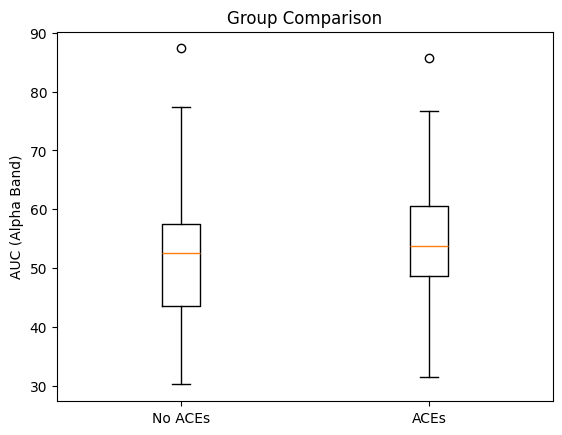

In [183]:
plt.figure()
plt.boxplot([no_aces_ec_auc, aces_ec_auc], labels=["No ACEs", "ACEs"])
plt.ylabel("AUC (Alpha Band)")
plt.title("Group Comparison")
plt.show()

In [184]:
print("No ACEs mean AUC EO:", np.mean(no_aces_eo_auc))
print("ACEs mean AUC EO:", np.mean(aces_eo_auc))

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(no_aces_eo_auc, aces_eo_auc)
print("t =", t_stat, "p =", p_val)

No ACEs mean AUC EO: 47.09504011534338
ACEs mean AUC EO: 49.33192976030027
t = -1.588020326420998 p = 0.11463855598997527


C:\Users\emros\AppData\Local\Temp\ipykernel_33984\2942184405.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_aces_eo_auc, aces_eo_auc], labels=["No ACEs", "ACEs"])


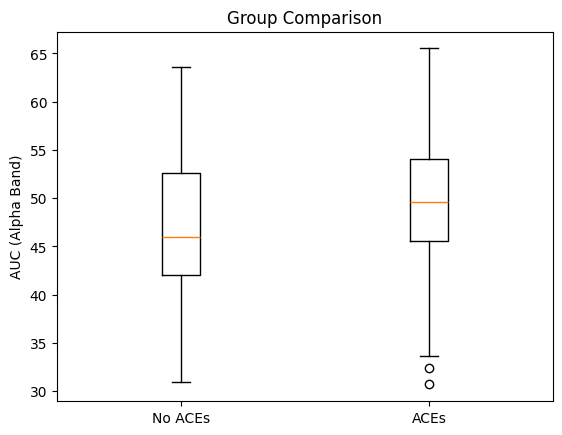

In [185]:
plt.figure()
plt.boxplot([no_aces_eo_auc, aces_eo_auc], labels=["No ACEs", "ACEs"])
plt.ylabel("AUC (Alpha Band)")
plt.title("Group Comparison")
plt.show()

In [186]:
print("No ACEs mean AUC DIFF:", np.mean(no_aces_auc_diff))
print("ACEs mean AUC DIFF:", np.mean(aces_auc_diff))

from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(no_aces_auc_diff, aces_auc_diff)
print("t =", t_stat, "p =", p_val)

No ACEs mean AUC DIFF: 0.2487915077193672
ACEs mean AUC DIFF: 0.21430290827597645
t = 0.14191466273212172 p = 0.8873621579168586


C:\Users\emros\AppData\Local\Temp\ipykernel_33984\2913438970.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no_aces_auc_diff, aces_auc_diff], labels=["No ACEs", "ACEs"])


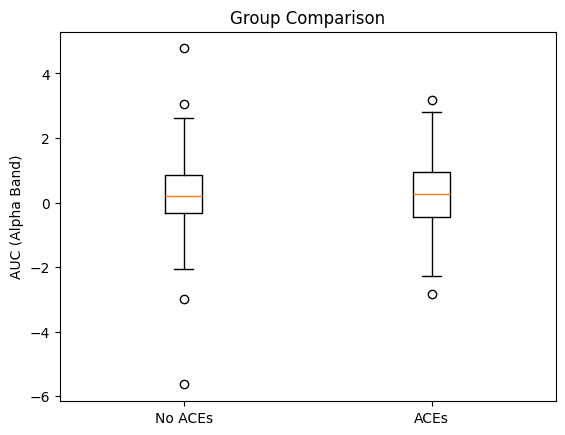

In [187]:
plt.figure()
plt.boxplot([no_aces_auc_diff, aces_auc_diff], labels=["No ACEs", "ACEs"])
plt.ylabel("AUC (Alpha Band)")
plt.title("Group Comparison")
plt.show()

# STATS

In [214]:
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, levene
import numpy as np

# -----------------------------
# 1. NORMALITY CHECK (important for t-test validity)
# -----------------------------
print("\nNormality (Shapiro-Wilk):")
print("No ACE EC:", shapiro(no_aces_ec_auc))
print("ACE EC:", shapiro(aces_ec_auc))



Normality (Shapiro-Wilk):
No ACE EC: ShapiroResult(statistic=np.float64(0.9677115480070341), pvalue=np.float64(0.2164064584465023))
ACE EC: ShapiroResult(statistic=np.float64(0.9933195294757688), pvalue=np.float64(0.7117120488266621))


In [215]:

# -----------------------------
# 2. VARIANCE CHECK
# -----------------------------
print("\nVariance equality (Levene):")
print(levene(no_aces_ec_auc, aces_ec_auc))


Variance equality (Levene):
LeveneResult(statistic=np.float64(2.421475625939788), pvalue=np.float64(0.12129535804705677))


In [216]:
# -----------------------------
# 3. PARAMETRIC TEST (t-test)
# -----------------------------
t_stat, p_val = ttest_ind(no_aces_ec_auc, aces_ec_auc, equal_var=False)
print("\nT-test (EC AUC):")
print("t =", t_stat, "p =", p_val)


T-test (EC AUC):
t = -1.5788469214306282 p = 0.11927343976667687


In [217]:
mannwhitneyu(no_aces_ec_auc, aces_ec_auc)

MannwhitneyuResult(statistic=np.float64(2936.0), pvalue=np.float64(0.07443484323270451))

In [218]:
# -----------------------------
# 4. BETWEEN-GROUP TESTS (EC)
# -----------------------------
t_stat_ec, p_t_ec = ttest_ind(no_aces_ec_auc, aces_ec_auc, equal_var=False)
u_stat_ec, p_u_ec = mannwhitneyu(no_aces_ec_auc, aces_ec_auc, alternative='two-sided')

print("\nT-test (EC AUC):", t_stat_ec, p_t_ec)
print("Mann-Whitney (EC AUC):", u_stat_ec, p_u_ec)


T-test (EC AUC): -1.5788469214306282 0.11927343976667687
Mann-Whitney (EC AUC): 2936.0 0.07443484323270451


In [219]:
# -----------------------------
# 5. EFFECT SIZE (Cohen's d)
# -----------------------------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / (nx+ny-2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std

d_ec = cohens_d(no_aces_ec_auc, aces_ec_auc)
print("\nCohen's d (EC):", d_ec)

# Rank-biserial correlation
n1, n2 = len(no_aces_ec_auc), len(aces_ec_auc)
rbc_ec = 1 - (2 * u_stat_ec) / (n1 * n2)
print("Rank-biserial correlation (EC):", rbc_ec)


Cohen's d (EC): -0.3001164324351985
Rank-biserial correlation (EC): 0.1726081442863182


In [220]:
# -----------------------------
# 6. WITHIN-GROUP (EC vs EO)
# -----------------------------
print("\n===== WITHIN GROUP (EC vs EO) =====")

# No ACEs
t_no_aces, p_no_aces = ttest_rel(no_aces_ec_auc, no_aces_eo_auc)
w_no_aces, pw_no_aces = wilcoxon(no_aces_ec_auc, no_aces_eo_auc)

print("No ACEs paired t-test:", t_no_aces, p_no_aces)
print("No ACEs Wilcoxon:", w_no_aces, pw_no_aces)

# ACEs
t_aces, p_aces = ttest_rel(aces_ec_auc, aces_eo_auc)
w_aces, pw_aces = wilcoxon(aces_ec_auc, aces_eo_auc)

print("ACEs paired t-test:", t_aces, p_aces)
print("ACEs Wilcoxon:", w_aces, pw_aces)


===== WITHIN GROUP (EC vs EO) =====


ValueError: Array shapes are incompatible for broadcasting.

In [221]:
print(type(no_aces_ec_auc), np.shape(no_aces_ec_auc))
print(type(no_aces_eo_auc), np.shape(no_aces_eo_auc))

print(type(aces_ec_auc), np.shape(aces_ec_auc))
print(type(aces_eo_auc), np.shape(aces_eo_auc))

<class 'numpy.ndarray'> (47,)
<class 'numpy.ndarray'> (48,)
<class 'numpy.ndarray'> (151,)
<class 'numpy.ndarray'> (88,)


In [222]:


# -----------------------------
# 7. INTERACTION EFFECT (difference of differences)
# -----------------------------
no_aces_diff = np.array(no_aces_ec_auc) - np.array(no_aces_eo_auc)
aces_diff = np.array(aces_ec_auc) - np.array(aces_eo_auc)

t_stat, p_val = ttest_ind(no_aces_diff, aces_diff, equal_var=False)
print("\nInteraction (EC-EO difference between groups):")
print("t =", t_stat, "p =", p_val)

# -----------------------------
# 8. BOOTSTRAP (robust confidence interval)
# -----------------------------
def bootstrap_ci(data, n_boot=1000):
    means = []
    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    return np.percentile(means, [2.5, 97.5])

ci_no_aces = bootstrap_ci(no_aces_ec_auc)
ci_aces = bootstrap_ci(aces_ec_auc)

print("\nBootstrap 95% CI:")
print("No ACEs:", ci_no_aces)
print("ACEs:", ci_aces)

ValueError: operands could not be broadcast together with shapes (47,) (48,) 

In [225]:
print(df.columns)
print(df.head())

Index(['subject', 'group', 'auc'], dtype='object')
  subject    group       auc
0   00641  no_aces -0.292490
1   00642  no_aces  0.910662
2    0717  no_aces -0.659564
3    0785  no_aces -0.619248
4    0798  no_aces -0.239217


In [227]:
from scipy.stats import ttest_ind

aces = df[df.group == "aces"]["auc"].values
no_aces = df[df.group == "no_aces"]["auc"].values

t, p = ttest_ind(aces, no_aces, equal_var=False)

print("t =", t)
print("p =", p)

t = -0.1323827960082835
p = 0.895024454835065


In [228]:
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(aces, no_aces, alternative="two-sided")

print("U =", u)
print("p =", p)

U = 1983.0
p = 0.6963219915490594
